[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/00_Mathematical_foundation/linear_algebra.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

# Linear Algebra

## Scalars, vectors, matrices and tensors

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(f"Pytorch version: {torch.__version__}")
print(f"Numpy version: {np.__version__}")

Pytorch version: 2.14.0
Numpy version: 2.4.6


## Scalars
- A scalar is a single number, represented as a 0-dimensional tensor in PyTorch. 
- In ML, scalars are used for learning rates, regularization parameters, loss values, etc.

In [4]:
s1 = 5.0 
s2_pt = torch.tensor(5.0) 
s3_pt = torch.tensor(3.14, dtype=torch.float32)

In [5]:
print(f"{s1}: type: {type(s1)}")
print(f"{s2_pt}: type: {type(s2_pt)}, shape: {s2_pt.shape}, dtype= {s2_pt.dtype}")
print(f"{s3_pt}: type: {type(s3_pt)}, shape: {s3_pt.shape}, dtype= {s3_pt.dtype}")

5.0: type: <class 'float'>
5.0: type: <class 'torch.Tensor'>, shape: torch.Size([]), dtype= torch.float32
3.140000104904175: type: <class 'torch.Tensor'>, shape: torch.Size([]), dtype= torch.float32


## Vectors (1-D Tensors)
- A vector is an ordered array of numbers, represented as a 1-D tensor.

In [6]:
v1_pt = torch.tensor([1.0, 2.0, 3.0])
v2_pt = torch.tensor([4.0, 5.5, 6.2], dtype=torch.float64)
# For row/column vectors, they are typically 2-D tensors with one dimension being 1
v_row_pt = torch.tensor([[7., 8., 9.]])      # Shape: (1, 3)
v_col_pt = torch.tensor([[10.], [11.], [12.]]) # Shape: (3, 1)

v3_np = np.array((1,2,3))

In [7]:
print(f"{v1_pt}, shape: {v1_pt.shape}, dtype: {v1_pt.dtype}")
print(f"\n{v2_pt}, shape: {v2_pt.shape}, dtype: {v2_pt.dtype}")
print(f"\nRow vector v_row_pt: {v_row_pt}, \nshape: {v_row_pt.shape}")
print(f"\nColumn vector v_col_pt: \n{v_col_pt}, \nshape: {v_col_pt.shape}")
print(f"\n{v3_np}: shape: {v3_np.shape}, dtype: {v3_np.dtype}")

tensor([1., 2., 3.]), shape: torch.Size([3]), dtype: torch.float32

tensor([4.0000, 5.5000, 6.2000], dtype=torch.float64), shape: torch.Size([3]), dtype: torch.float64

Row vector v_row_pt: tensor([[7., 8., 9.]]), 
shape: torch.Size([1, 3])

Column vector v_col_pt: 
tensor([[10.],
        [11.],
        [12.]]), 
shape: torch.Size([3, 1])

[1 2 3]: shape: (3,), dtype: int64


In [8]:
# Addition
v_sum_pt = v1_pt + v2_pt.to(v1_pt.dtype) # Ensure same dtype for operations
print(f"\n({v1_pt} + {v2_pt}) = {v_sum_pt}")


(tensor([1., 2., 3.]) + tensor([4.0000, 5.5000, 6.2000], dtype=torch.float64)) = tensor([5.0000, 7.5000, 9.2000])


In [9]:
# multiplication
v_scaled_pt = 5 * v1_pt  
print(f"Vector scaled (5 * {v1_pt}) =  {v_scaled_pt}")

Vector scaled (5 * tensor([1., 2., 3.])) =  tensor([ 5., 10., 15.])


In [10]:
# Dot Product 
# Result is a scalar (0-D tensor).
dot_product_v1_v2_pt = v1_pt @ v2_pt.to(v1_pt.dtype)
print(f"Dot product ({v1_pt} . {v2_pt}) =  {dot_product_v1_v2_pt}")

Dot product (tensor([1., 2., 3.]) . tensor([4.0000, 5.5000, 6.2000], dtype=torch.float64)) =  33.599998474121094


In [11]:
# Norm
# L2 norm (Euclidean norm)
norm_v1_pt = torch.linalg.norm(v1_pt)
print(f"L2 Norm of v1_pt: {norm_v1_pt:.4f}")

L2 Norm of v1_pt: 3.7417


In [12]:
# L1 norm
norm_l1_v1_pt = torch.linalg.norm(v1_pt, ord=1)
print(f"L1 Norm of v1_pt: {norm_l1_v1_pt}")

L1 Norm of v1_pt: 6.0


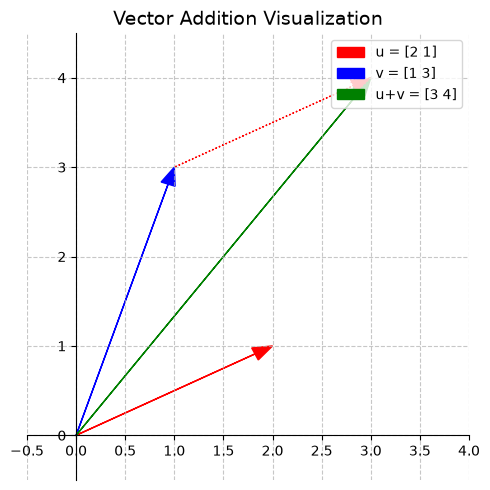

In [13]:
"""
This code was generated from claude
"""

u = np.array([2, 1])
v = np.array([1, 3])
u_plus_v = u + v

fig, ax = plt.subplots(figsize=(5, 5))

vectors = [(u, 'red', 'u'), (v, 'blue', 'v'), (u_plus_v, 'green', 'u+v')]
for vec, color, name in vectors:
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, head_length=0.2, 
             fc=color, ec=color, length_includes_head=True, label=f'{name} = {vec}')

ax.arrow(v[0], v[1], u[0], u[1], head_width=0.15, head_length=0.2, 
         fc='red', ec='red', length_includes_head=True, linestyle='dotted')

# Enhanced styling for better readability
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4.5)
ax.grid(linestyle='--', alpha=0.7)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_title("Vector Addition Visualization", fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Matrices (2-D Tensors)
- A matrix is a 2D array of numbers, represented as a 2-D tensor. 

In [14]:
M1_pt = torch.tensor([[1., 2., 3.],
                      [4., 5., 6.]]) # 2x3 matrix

M2_pt = torch.tensor([[7., 8.],
                      [9., 10.],
                      [11., 12.]]) # 3x2 matrix

M_square_pt = torch.tensor([[1., 2.],
                            [3., 4.]]) # 2x2 square matrix

In [15]:
print(f"Matrix M1_pt (2x3):\n{M1_pt}\nshape: {M1_pt.shape}, dtype: {M1_pt.dtype}")
print(f"\nMatrix M2_pt (3x2):\n{M2_pt}\nshape: {M2_pt.shape}")
print(f"\nMatrix M_square_pt (2x2):\n{M_square_pt}\nshape: {M_square_pt.shape}")


Matrix M1_pt (2x3):
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3]), dtype: torch.float32

Matrix M2_pt (3x2):
tensor([[ 7.,  8.],
        [ 9., 10.],
        [11., 12.]])
shape: torch.Size([3, 2])

Matrix M_square_pt (2x2):
tensor([[1., 2.],
        [3., 4.]])
shape: torch.Size([2, 2])


In [16]:
# Addition (matrices must have same dimensions)
M3_pt = torch.tensor([[0.1, 0.2, 0.3],
                      [0.4, 0.5, 0.6]])
M_sum_pt = M1_pt + M3_pt
print(f"\nMatrix sum (\n{M1_pt} + \n{M3_pt}) = \n{M_sum_pt}")


Matrix sum (
tensor([[1., 2., 3.],
        [4., 5., 6.]]) + 
tensor([[0.1000, 0.2000, 0.3000],
        [0.4000, 0.5000, 0.6000]])) = 
tensor([[1.1000, 2.2000, 3.3000],
        [4.4000, 5.5000, 6.6000]])


In [17]:
# Scalar multiplication
M_scaled_pt = 5 * M1_pt
print(f"Matrix scaled (5 * M1_pt) = \n{M_scaled_pt}")

Matrix scaled (5 * M1_pt) = 
tensor([[ 5., 10., 15.],
        [20., 25., 30.]])


In [18]:
# Matrix Transpose
# Swaps rows and columns.
M1_T_pt = M1_pt.T # or torch.transpose(M1_pt, 0, 1)
print(f"Transpose of M1_pt = \n{M1_T_pt}\nshape : {M1_pt.shape} ---> {M1_T_pt.shape}")


Transpose of M1_pt = 
tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])
shape : torch.Size([2, 3]) ---> torch.Size([3, 2])


In [19]:
# Matrix Multiplication
# torch.matmul() or the @ operator
# Number of columns in the first matrix must equal number of rows in the second.
M_prod_pt = torch.matmul(M1_pt, M2_pt) # or M1_pt @ M2_pt
print(f"Matrix product (M1_pt @ M2_pt) (2x3 @ 3x2 = 2x2) = \n{M_prod_pt}")

Matrix product (M1_pt @ M2_pt) (2x3 @ 3x2 = 2x2) = 
tensor([[ 58.,  64.],
        [139., 154.]])


In [20]:
# Matrix-vector multiplication
# M1_pt is 2x3, v1_pt is 1D (3). torch.matmul handles broadcasting correctly.
Mv_prod_pt = torch.matmul(M1_pt, v1_pt)
print(f"Matrix-vector product (M1_pt @ v1_pt):\n{Mv_prod_pt}, shape: {Mv_prod_pt.shape}")

Matrix-vector product (M1_pt @ v1_pt):
tensor([14., 32.]), shape: torch.Size([2])


In [21]:
# If v1_pt needs to be explicitly a column vector (3,1)
v1_col_pt = v1_pt.reshape(-1, 1) # or 
# v1_pt.unsqueeze(1)
print(f"Vector v1_pt = {v1_pt}")
print(f"\nUnsqueezed vector = \n{v1_col_pt}")

Vector v1_pt = tensor([1., 2., 3.])

Unsqueezed vector = 
tensor([[1.],
        [2.],
        [3.]])


In [22]:
Mv_prod_explicit_col_pt = M1_pt @ v1_col_pt
print(f"Matrix-vector product (M1_pt @ v1_col_pt) with explicit column vector:\n{Mv_prod_explicit_col_pt}")

Matrix-vector product (M1_pt @ v1_col_pt) with explicit column vector:
tensor([[14.],
        [32.]])


In [23]:
# Identity Matrix
I_3_pt = torch.eye(3) # 3x3 identity matrix
print(f"\n3x3 Identity Matrix (I_3_pt):\n{I_3_pt}")


3x3 Identity Matrix (I_3_pt):
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [24]:
# Inverse of a Matrix
# Only non-singular square matrices have an inverse.
try:
    M_square_inv_pt = torch.linalg.inv(M_square_pt)
    print(f"\nInverse of M_square_pt:\n{M_square_inv_pt}")
    # Verification: M_square_pt @ M_square_inv_pt should be close to identity
    verification_inv = M_square_pt @ M_square_inv_pt
    print(f"Verification (M_square_pt @ M_square_inv_pt):\n{verification_inv}")
    # torch.allclose checks if two tensors are element-wise equal within a tolerance
    print(f"Is it close to identity? {torch.allclose(verification_inv, torch.eye(2, dtype=M_square_pt.dtype))}")
except RuntimeError as e:
    print(f"\nCould not compute inverse of M_square_pt: {e}")


Inverse of M_square_pt:
tensor([[-2.0000,  1.0000],
        [ 1.5000, -0.5000]])
Verification (M_square_pt @ M_square_inv_pt):
tensor([[ 1.0000e+00,  0.0000e+00],
        [-4.7684e-07,  1.0000e+00]])
Is it close to identity? False


## Eigenvalues and Eigenvectors
- For a square matrix A, `Av = λv`.
- `torch.linalg.eig()` for general matrices (eigenvalues can be complex).
- `torch.linalg.eigh()` for real symmetric or complex Hermitian matrices (eigenvalues are real).

In [25]:
mat_sym_pt = torch.tensor([[4., 1.],
                           [1., 3.]])

In [26]:
eigenvalues_sym, eigenvectors_sym = torch.linalg.eigh(mat_sym_pt, UPLO='U')

In [27]:
print(f"Eigenvalues (λ) from eigh = {eigenvalues_sym}\nEigenvectors (V) from eigh = \n{eigenvectors_sym}")

Eigenvalues (λ) from eigh = tensor([2.3820, 4.6180])
Eigenvectors (V) from eigh = 
tensor([[ 0.5257, -0.8507],
        [-0.8507, -0.5257]])


In [28]:
# Verification
lambda_1_pt = eigenvalues_sym[0]
v_1_pt = eigenvectors_sym[:, 0]

In [29]:
lhs_pt = mat_sym_pt @ v_1_pt

In [30]:
print(f"\nLeft Hand Side (A_sym_pt @ v_1_pt):\n{lhs_pt}")


Left Hand Side (A_sym_pt @ v_1_pt):
tensor([ 1.2523, -2.0262])


In [31]:
rhs_pt = lambda_1_pt * v_1_pt
print(f"Right Hand Side (λ_1_pt * v_1_pt):\n{rhs_pt}")

Right Hand Side (λ_1_pt * v_1_pt):
tensor([ 1.2523, -2.0262])


In [32]:
{torch.allclose(lhs_pt, rhs_pt)}

{True}

In [33]:
# Eigen-decomposition reconstruction: A = V @ diag(Λ) @ V.T
V_pt = eigenvectors_sym
Lambda_diag_pt = torch.diag(eigenvalues_sym)
Mat_reconstructed_pt = V_pt @ Lambda_diag_pt @ V_pt.T

In [34]:
print(f"\nReconstructed mat_sym_pt using V @ diag(Λ) @ V.T:\n{Mat_reconstructed_pt}")


Reconstructed mat_sym_pt using V @ diag(Λ) @ V.T:
tensor([[4.0000, 1.0000],
        [1.0000, 3.0000]])


In [35]:
{torch.allclose(mat_sym_pt, Mat_reconstructed_pt)}

{True}

In [36]:
# For general (non-symmetric) matrices --> torch.linalg.eig()
Mat_general_pt = torch.tensor([[4., -2.], [1., 1.]], dtype=torch.float32)

In [37]:
eigenvalues_gen, eigenvectors_gen = torch.linalg.eig(Mat_general_pt)

In [38]:
print(f"Eigenvalues (λ) from eig for general matrix = \n{eigenvalues_gen}")
print(f"\nEigenvectors (V) from eig for general matrix = \n{eigenvectors_gen}")

Eigenvalues (λ) from eig for general matrix = 
tensor([3.+0.j, 2.+0.j])

Eigenvectors (V) from eig for general matrix = 
tensor([[0.8944+0.j, 0.7071+0.j],
        [0.4472+0.j, 0.7071+0.j]])


> **Note:** eigenvalues and eigenvectors may be complex. The matrix is reconstructed as `V @ diag(L) @ V_inv`.

## Singular Value Decomposition (SVD)
- `A = U @ diag(S) @ Vh` (where Vh = V.conj().T)
- U = Left singular vectors
- S = Singular values (1D tensor)
- Vh = Conjugate transpose of right singular vectors

In [39]:
B_pt = torch.tensor([[1., 2., 3.],
                     [4., 5., 6.]])

In [40]:
U_pt, S_pt, Vh_pt = torch.linalg.svd(B_pt)

In [41]:
print(f"\nU (Left singular vectors):\n{U_pt}\nshape: {U_pt.shape}")
print(f"\nS (Singular values - 1D tensor):\n{S_pt}\nshape: {S_pt.shape}")
print(f"\nVh (V conjugate transpose - Right singular vectors as rows of V):\n{Vh_pt}\nshape: {Vh_pt.shape}")


U (Left singular vectors):
tensor([[-0.3863, -0.9224],
        [-0.9224,  0.3863]])
shape: torch.Size([2, 2])

S (Singular values - 1D tensor):
tensor([9.5080, 0.7729])
shape: torch.Size([2])

Vh (V conjugate transpose - Right singular vectors as rows of V):
tensor([[-0.4287, -0.5663, -0.7039],
        [ 0.8060,  0.1124, -0.5812],
        [ 0.4082, -0.8165,  0.4082]])
shape: torch.Size([3, 3])


In [42]:
# Construct Sigma (Σ) matrix from singular values S_pt
Sigma_pt = torch.zeros(B_pt.shape[0], B_pt.shape[1], dtype=B_pt.dtype)
# Populate the diagonal part of Sigma_pt
num_singular_values_pt = min(B_pt.shape)
Sigma_pt[:num_singular_values_pt, :num_singular_values_pt] = torch.diag(S_pt)

In [43]:
print(f"\nConstructed Sigma_pt (Σ) matrix:\n{Sigma_pt}")


Constructed Sigma_pt (Σ) matrix:
tensor([[9.5080, 0.0000, 0.0000],
        [0.0000, 0.7729, 0.0000]])


In [44]:
# Reconstruct B_pt: B_reconstructed_pt = U_pt @ Sigma_pt @ Vh_pt
B_reconstructed_pt = U_pt @ Sigma_pt @ Vh_pt

In [45]:
torch.allclose(B_pt, B_reconstructed_pt)

True

In [46]:
# Low-rank approximation using SVD
k_pt = 1
Sigma_k_pt = torch.zeros(B_pt.shape[0], B_pt.shape[1], dtype=B_pt.dtype)
Sigma_k_pt[:k_pt, :k_pt] = torch.diag(S_pt[:k_pt])

In [47]:
B_approx_k1_pt = U_pt @ Sigma_k_pt @ Vh_pt

In [48]:
B_approx_k1_pt

tensor([[1.5745, 2.0801, 2.5857],
        [3.7594, 4.9664, 6.1735]])

## Conversion between NumPy and PyTorch

In [49]:
# NumPy to PyTorch
np_array = np.array([[1,2],[3,4]])

In [50]:
pt_tensor_from_np = torch.from_numpy(np_array)

In [51]:
np_array.dtype, pt_tensor_from_np.dtype

(dtype('int64'), torch.int64)

In [52]:
# PyTorch to NumPy
# If a tensor is on GPU or requires grad, you need .cpu() and .detach()
pt_tensor_to_convert = torch.tensor([[5., 6.], [7., 8.]])

In [53]:
np_array_from_pt = pt_tensor_to_convert.numpy()

In [54]:
pt_tensor_to_convert.dtype, np_array_from_pt.dtype

(torch.float32, dtype('float32'))

In [55]:
# If tensor might require grad
x_grad = torch.tensor([[1.,2.], [3.,4.]], requires_grad=True)

In [56]:
# Calling .numpy() directly on a tensor that requires grad raises an error
try:
    x_grad.numpy()
except RuntimeError as e:
    print(f"RuntimeError: {e}")

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.


In [57]:
x_np = x_grad.detach().numpy() # detach creates a new tensor that doesn't require grad

In [58]:
x_np.dtype

dtype('float32')